# Lab 6 - Mathematical Distributions

In [1]:
%matplotlib inline

This will make all the `matplotlib` images appear in the notebook.

## General Instructions

In this course, Labs are the chance to applying concepts and methods discussed in the module.
They are a low stakes (pass/fail) opportunity for you to try your hand at *doing*.
Please make sure you follow the general Lab instructions, described in the Syllabus.
The summary is:

* Discussions should start as students work through the material, first Wednesday at the start of the new Module week. 
* Labs are due by Sunday. 
* Lab solutions are released Monday.  
* Post Self Evaluation and Lab to Lab Group on Blackboard and Lab to Module on Blackboard on Monday.

The last part is important because the Problem Sets will require you to perform the same or similar tasks without guidance.
Problem Sets are your opportunity to demonstrate that you understand how to apply the concepts and methods discussed in the relevant Modules and Labs.

## Specific Instructions

1.  For Blackboard submissions, if there are no accompanying files, you should submit *only* your notebook and it should be named using *only* your JHED id: fsmith79.ipynb for example if your JHED id were "fsmith79". If the assignment requires additional files, you should name the *folder/directory* your JHED id and put all items in that folder/directory, ZIP it up (only ZIP...no other compression), and submit it to Blackboard.

    * do **not** use absolute paths in your notebooks. All resources should located in the same directory as the rest of your assignments.
    * the directory **must** be named your JHED id and **only** your JHED id.
    * do **not** return files provided by us (data files, .py files)


2. Data Science is as much about what you write (communicating) as the code you execute (researching). In many places, you will be required to execute code and discuss both the purpose and the result. Additionally, Data Science is about reproducibility and transparency. This includes good communication with your team and possibly with yourself. Therefore, you must show **all** work.

3. Avail yourself of the Markdown/Codecell nature of the notebook. If you don't know about Markdown, look it up. Your notebooks should not look like ransom notes. Don't make everything bold. Clearly indicate what question you are answering.

4. Submit a cleanly executed notebook. The first code cell should say `In [1]` and each successive code cell should increase by 1 throughout the notebook.

In [2]:
import numpy as np
import random as py_random
import numpy.random as np_random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from pprint import pprint

sns.set(style="whitegrid")
rng = np.random.default_rng(42)  # reproducible bootstrap

## Problem 1

The following data are measurements (in millimeters) of rainbow trout caught in the Arolik River of Alaska.

1. Do EDA for the variable.
2. Create a mean model with error bounds using the more appropriate approach, and interpret the model.
3. What do you think the data generating story is?
4. Create a distributional model for the data and make three predictions with it.

In [3]:
trout = [572.4, 417.9, 423.3, 559.9, 459.0, 416.9, 534.4, 464.4, 476.3, 423.9, 466.0,
 437.0, 471.4, 486.2, 483.5, 470.0, 533.7, 419.5, 475.5, 485.8, 533.7, 529.5,
 464.6, 436.3, 448.0, 523.8, 457.2, 456.1, 458.0, 583.9, 455.7, 461.4, 482.9,
 505.5, 373.4, 372.3, 518.0, 472.6, 529.9, 536.3, 509.6, 475.3, 471.9, 477.1,
 488.5, 458.6, 543.6, 499.5]

### 1. EDA

We start by looking at the shape, center, and spread of the trout length measurements.

count     48.000000
mean     479.170833
std       46.597274
min      372.300000
25%      456.925000
50%      473.950000
75%      511.700000
max      583.900000
dtype: float64

skewness: 0.043


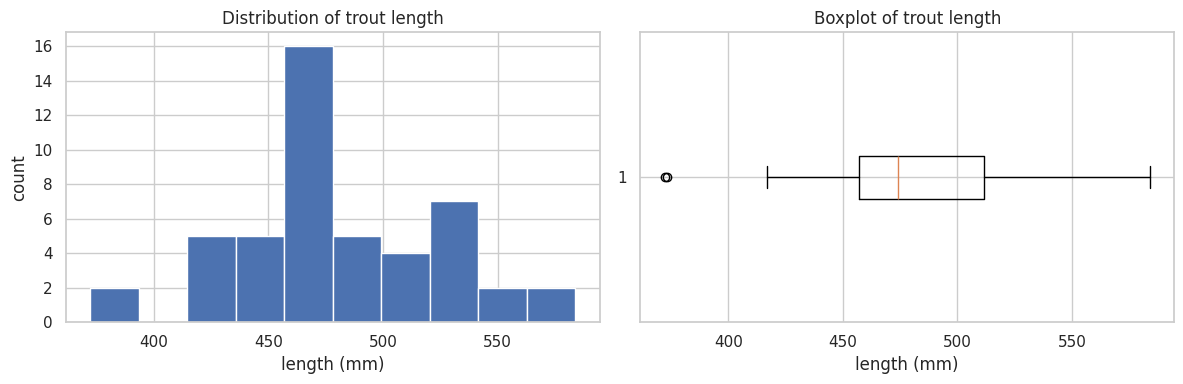

In [ ]:
trout = np.array(trout)

# Numeric summary
desc = pd.Series(trout).describe()
print(desc)
print(f"\nskewness: {stats.skew(trout):.3f}")

# Histogram + boxplot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(trout, bins=10, edgecolor="white")
ax1.set_xlabel("length (mm)")
ax1.set_ylabel("count")
ax1.set_title("Distribution of trout length")
ax2.boxplot(trout, vert=False)
ax2.set_xlabel("length (mm)")
ax2.set_title("Boxplot of trout length")
plt.tight_layout()
plt.show()

**Discussion.** The 48 measurements are centered around a mean of ~479 mm and a median of ~474 mm, which are very close together. The spread (std ~47 mm) is moderate, the histogram is roughly bell-shaped and symmetric, the boxplot shows no outliers, and the skewness (~0.04) is essentially zero. This all points to a symmetric, roughly normal variable.

### 2. Mean model with error bounds

Because the variable is roughly normal with no outliers, the symmetric normal interval is appropriate: the sampling distribution of the mean is well-approximated by a *t* distribution, so the mean ± t·SEM interval is valid. (We can confirm this with a bootstrap, which makes no normality assumption so if the two agree, the interval is trustworthy.)

In [5]:
n = len(trout)
mean = np.mean(trout)
std = np.std(trout, ddof=1)           # ddof=1 -> sample std
sem = std / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
ci = t_crit * sem

print(f"Mean model (95% t-CI): {mean:.2f} ± {ci:.2f}")
print(f"Bounds: [{mean - ci:.2f}, {mean + ci:.2f}]")

# Bootstrap check (no normality assumption)
boot_means = [np.mean(rng.choice(trout, n, replace=True)) for _ in range(10000)]
lo, hi = np.percentile(boot_means, [2.5, 97.5])
print(f"Bootstrap 95% CI:      [{lo:.2f}, {hi:.2f}]")

Mean model (95% t-CI): 479.17 ± 13.53
Bounds: [465.64, 492.70]
Bootstrap 95% CI:      [465.97, 492.15]


**Interpretation.** Our best estimate of the average trout length is 479.2 mm, and we are 95% confident the true population mean lies in roughly [465.6, 492.7] mm. The bootstrap interval is nearly identical, which confirms the normal interval is appropriate here.

### 3. Data generating story

A fish's length is the result of many small, independent factors like genetics, food intake, water temperature, age, etc. When a measurement is the sum of many small independent effects, the Central Limit Theorem suggests the result will be approximately normally distributed. The symmetric bell shape we observed in the histogram is consistent with that story, so a Normal distribution is a reasonable generative model.

### 4. Distributional model + three predictions

I fit a Normal distribution using the sample mean and sample standard deviation as estimates of μ and σ, then use it to make three predictions. A formal normality test backs up the choice.

Shapiro-Wilk: W=0.976, p=0.425  ->  p > 0.05, fail to reject normality

Fitted Normal: mu=479.17, sigma=46.60


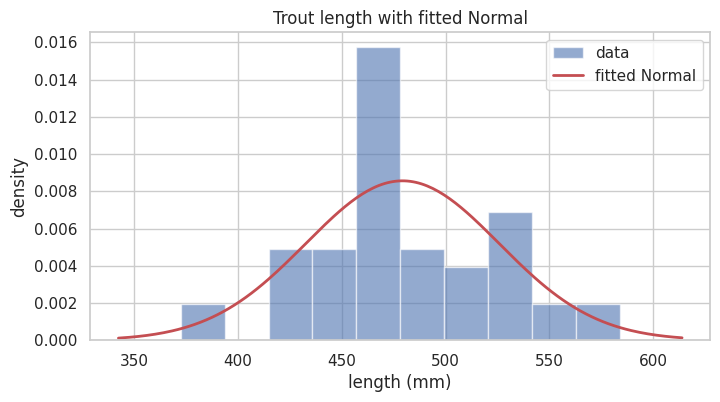


(a) P(length > 500 mm) = 0.327
(b) 90th percentile length = 538.9 mm
(c) 95% prediction interval for one new trout = [384.5, 573.9] mm


In [ ]:
# Normality test (Shapiro-Wilk is appropriate for small n)
stat, p = stats.shapiro(trout)
print(f"Shapiro-Wilk: W={stat:.3f}, p={p:.3f}  ->  p > 0.05, fail to reject normality")

# Fit Normal
mu, sigma = mean, std
print(f"\nFitted Normal: mu={mu:.2f}, sigma={sigma:.2f}")

# Overlay fitted density on the histogram
xs = np.linspace(trout.min()-30, trout.max()+30, 200)
plt.figure(figsize=(8,4))
plt.hist(trout, bins=10, density=True, edgecolor="white", alpha=0.6, label="data")
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), "r-", lw=2, label="fitted Normal")
plt.xlabel("length (mm)")
plt.ylabel("density")
plt.title("Trout length with fitted Normal")
plt.legend()
plt.show()

# --- Three predictions ---
# (a) Probability a randomly caught trout exceeds 500 mm
p_gt_500 = 1 - stats.norm.cdf(500, mu, sigma)
print(f"\n(a) P(length > 500 mm) = {p_gt_500:.3f}")

# (b) 90th percentile length
p90 = stats.norm.ppf(0.90, mu, sigma)
print(f"(b) 90th percentile length = {p90:.1f} mm")

# (c) 95% prediction interval for a SINGLE new trout
#     uses sigma, with sqrt(1 + 1/n) for estimation error
margin = t_crit * sigma * np.sqrt(1 + 1/n)
print(f"(c) 95% prediction interval for one new trout = [{mu - margin:.1f}, {mu + margin:.1f}] mm")

**Interpretation of predictions.** 
- (a) About a 33% chance a caught trout is longer than 500 mm.
- (b) 90% of trout are shorter than ~539 mm. 
- (c) A single new trout will fall in roughly [384, 574] mm with 95% probability.

## Problem 2

The following data represent the number of days it takes a software team to clear tickets.

1. Do EDA for the variable.
2. Create a mean model with error bounds using the more appropriate approach, and interpret the model.
3. What do you think the data generating story is?
4. Create a distributional model for the data and make three predictions with it.

In [7]:
days = [8.0, 3.8, 4.0, 1.6, 2.6, 3.4, 8.7, 4.7, 6.1, 1.9, 6.0, 8.2, 2.7, 6.5, 1.9, 2.7,
 1.6, 1.3, 2.3, 3.3, 9.8, 8.3, 3.3, 4.3, 4.7, 7.2, 5.8, 3.3, 2.0, 3.2, 1.7, 2.5,
 1.6, 4.0, 4.1, 1.0, 2.7, 5.3, 7.6, 1.5, 7.1, 2.5, 2.6, 4.0, 1.3, 7.0, 4.0, 8.4,
 1.3, 5.1, 6.4, 3.1, 1.5, 4.1, 2.5, 5.5, 2.4, 1.4, 2.6, 1.9, 2.1, 2.0, 2.5, 2.2,
 2.6, 3.1, 3.6, 1.8, 3.1, 4.6, 1.2, 5.4, 6.5, 7.0, 9.7, 6.6, 9.1, 6.9, 2.5, 8.5,
 5.0, 3.2, 0.9, 3.3, 2.9, 3.9, 12.1, 3.4, 2.9, 4.6, 4.5, 1.7, 1.2, 3.6, 3.9,
 14.2, 5.3, 1.2, 0.3, 2.3, 2.9, 2.5, 0.8, 1.6, 2.7, 4.6, 4.4, 2.7, 3.5, 0.6,
 4.9, 2.2, 5.4, 6.0, 1.8, 1.0, 1.5, 4.0, 2.1, 5.6, 4.1, 1.9, 1.7, 3.8, 5.7, 4.1,
 2.3, 5.1, 8.4, 4.8, 3.7, 2.2, 2.6, 2.8, 0.5, 3.9, 2.9, 3.7, 2.6, 2.5, 11.7,
 3.3, 1.5, 7.3, 1.1, 0.3, 0.9, 0.5, 8.4, 2.8, 6.1, 3.4, 4.7, 10.0, 1.9, 5.8,
 6.4, 4.6, 0.4, 6.8, 5.3, 3.9, 1.2, 2.6, 3.4, 2.4, 3.7, 14.5, 10.3, 0.1, 0.8,
 0.4, 9.8, 6.3, 4.5, 1.0, 2.8, 5.6, 1.4, 1.7, 2.5, 1.7, 1.6, 23.0, 0.2, 3.1,
 1.5, 0.7, 2.4, 4.2, 3.0, 2.0, 8.3, 2.5, 4.4, 3.0, 5.2, 4.3, 4.7, 5.4, 1.1, 1.8,
 9.9, 2.9, 3.0, 5.8, 2.0, 0.6, 3.1, 8.2, 5.7, 4.7, 8.4, 4.1, 3.4, 2.7, 9.3, 0.6,
 0.5, 1.8, 8.4, 3.4, 10.9, 6.0, 11.3, 2.9, 1.9, 3.3, 1.7, 11.5, 6.9, 6.4, 7.4,
 2.4, 1.3, 0.7, 15.5, 4.2, 2.5, 2.0, 6.2, 3.7, 3.5, 5.3, 4.1, 2.6, 0.9, 3.1,
 1.5, 1.7, 1.8, 0.9, 0.7, 1.2, 5.0, 3.8, 3.7, 7.2, 4.0, 2.9, 16.4, 1.2, 6.8,
 0.5, 2.4, 7.7, 5.5, 4.6, 5.5, 0.3, 4.2, 5.1, 0.5, 7.0, 1.1, 0.6, 0.8, 2.2, 8.6,
 1.5, 2.8, 3.2, 7.4, 3.6, 7.9, 3.0, 3.4, 4.8, 1.9, 1.6, 0.7, 4.6, 4.3, 2.6, 7.4,
 0.1, 1.8, 6.7, 0.4, 2.0, 2.8, 2.4, 5.4, 1.2, 4.2, 3.8, 5.6, 3.0, 2.8, 5.4, 6.7,
 2.5, 3.4, 5.0, 3.7, 2.4, 3.6, 5.9, 1.9, 9.9, 4.0, 4.9, 1.9, 2.9, 3.9, 2.9, 5.5,
 8.1, 3.6, 2.1, 5.1, 11.1, 9.0, 1.8, 3.7, 1.0, 1.4, 3.9, 3.2, 0.9, 2.0, 4.5,
 2.5, 7.5, 2.5, 1.5, 0.6, 3.1, 6.0, 2.6, 1.9, 5.5, 8.7, 1.4, 2.9, 1.2, 8.1, 4.8,
 3.8, 0.6, 3.1, 6.5, 5.4, 6.3, 4.3, 7.1, 5.2, 3.7, 3.4, 1.9, 1.9, 1.0, 6.5, 2.8,
 3.6, 2.2, 3.8, 5.9, 4.6, 5.4, 2.9, 1.1, 9.5, 5.0, 13.2, 5.7, 2.2, 4.2, 3.8,
 1.4, 1.0, 2.0, 6.3, 1.8, 4.2, 1.8, 2.2, 12.4, 5.9, 5.3, 1.1, 5.6, 4.6, 2.4,
 5.4, 4.5, 0.9, 5.5, 13.9, 0.8, 3.1, 1.3, 5.7, 6.3, 2.5, 0.5, 10.1, 1.4, 1.5,
 3.8, 1.6, 4.7, 5.8]

### 1. EDA

count    423.000000
mean       4.030969
std        2.937204
min        0.100000
25%        1.900000
50%        3.400000
75%        5.400000
max       23.000000
dtype: float64

skewness: 1.755
zeros in data: 0  (matters for log transform)


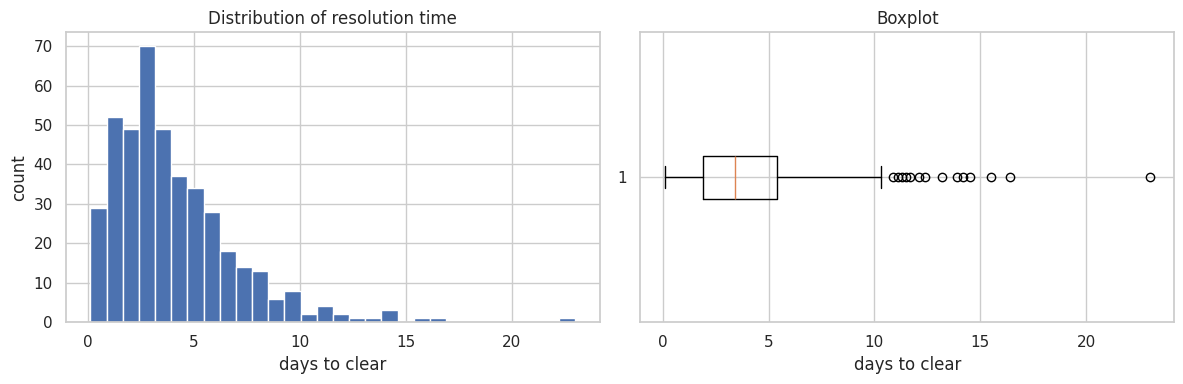

In [8]:
days = np.array(days)

print(pd.Series(days).describe())
print(f"\nskewness: {stats.skew(days):.3f}")
print(f"zeros in data: {(days == 0).sum()}  (matters for log transform)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.hist(days, bins=30, edgecolor="white")
ax1.set_xlabel("days to clear"); ax1.set_ylabel("count")
ax1.set_title("Distribution of resolution time")
ax2.boxplot(days, vert=False)
ax2.set_xlabel("days to clear"); ax2.set_title("Boxplot")
plt.tight_layout(); plt.show()

**Discussion.** With n=423, the data are strongly **right-skewed** (skew ~1.8): most tickets clear in a few days (median ~3.4) but a long right tail stretches out to 23 days, pulling the mean (~4.0) above the median. Values are strictly positive and there are no zeros. This is the classic shape of a waiting-time / duration variable — very different from the symmetric trout data.

### 2. Mean model with error bounds

Because the distribution is **skewed**, the symmetric normal-theory interval is less trustworthy here — the assumption that the mean's sampling distribution is symmetric is weaker. The **more appropriate approach is the bootstrap**, which makes no symmetry/normality assumption. We compute both and compare.

In [9]:
n = len(days)
mean = np.mean(days)
std = np.std(days, ddof=1)
sem = std / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)

# Normal-theory (for comparison)
nt_lo, nt_hi = mean - t_crit*sem, mean + t_crit*sem

# Bootstrap (preferred)
boot_means = [np.mean(rng.choice(days, n, replace=True)) for _ in range(10000)]
bs_lo, bs_hi = np.percentile(boot_means, [2.5, 97.5])

print(f"Mean estimate: {mean:.2f} days")
print(f"Normal-theory 95% CI: [{nt_lo:.2f}, {nt_hi:.2f}]")
print(f"Bootstrap     95% CI: [{bs_lo:.2f}, {bs_hi:.2f}]  <- preferred")

Mean estimate: 4.03 days
Normal-theory 95% CI: [3.75, 4.31]
Bootstrap     95% CI: [3.76, 4.32]  <- preferred


**Interpretation.** The team takes about **4.0 days** on average to clear a ticket, with a 95% bootstrap CI of roughly **[3.76, 4.33]** days. Here n is large (423), so the CLT still pulls the two intervals close together — but the bootstrap is the principled choice for skewed data because it doesn't assume the sampling distribution is symmetric.

### 3. Data generating story

Resolution times are **positive, continuous, right-skewed durations**. Two common generative stories fit this shape: (i) an **exponential** process, where tickets clear at a roughly constant hazard rate; or (ii) a **lognormal** process, where total time is the *product* of many independent multiplicative factors (triage delay × investigation × fix × review), so the *log* of the time is a sum of small effects and is therefore normal. Below we check the lognormal story directly by log-transforming.

### 4. Distributional model + three predictions

If the data are lognormal, then log(days) should look approximately normal. We check that, then fit a lognormal and make three predictions.

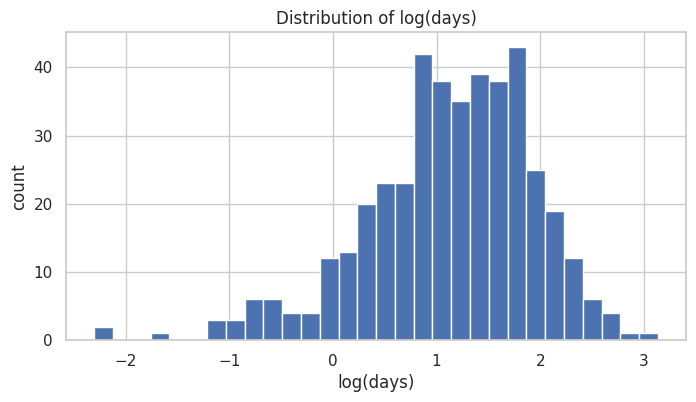

skew of log(days): -0.812  (much closer to 0)
Fitted lognormal: sigma=0.810, mu=1.119


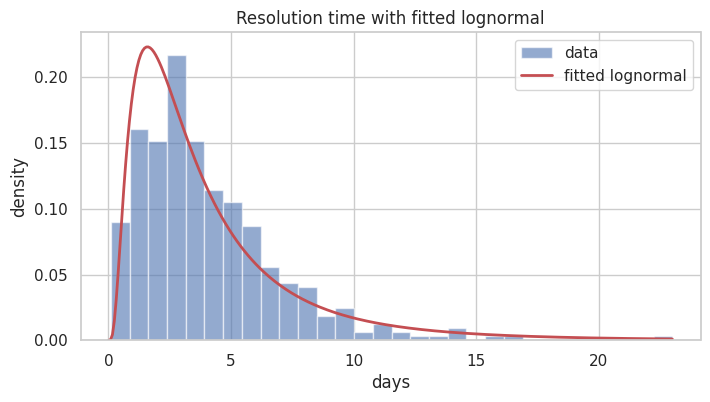


(a) P(ticket takes > 10 days) = 0.072
(b) Predicted median resolution time = 3.06 days
(c) 95% of tickets clear within 11.6 days


In [10]:
# Log transform and check for normality on the log scale
days_log = np.log(days)
plt.figure(figsize=(8,4))
plt.hist(days_log, bins=30, edgecolor="white")
plt.xlabel("log(days)"); plt.ylabel("count")
plt.title("Distribution of log(days)"); plt.show()
print(f"skew of log(days): {stats.skew(days_log):.3f}  (much closer to 0)")

# Fit lognormal (floc=0 fixes the location so it's a true 2-parameter lognormal)
shape, loc, scale = stats.lognorm.fit(days, floc=0)
print(f"Fitted lognormal: sigma={shape:.3f}, mu={np.log(scale):.3f}")

# Overlay
xs = np.linspace(0.01, days.max(), 300)
plt.figure(figsize=(8,4))
plt.hist(days, bins=30, density=True, edgecolor="white", alpha=0.6, label="data")
plt.plot(xs, stats.lognorm.pdf(xs, shape, loc, scale), "r-", lw=2, label="fitted lognormal")
plt.xlabel("days"); plt.ylabel("density"); plt.legend()
plt.title("Resolution time with fitted lognormal"); plt.show()

# --- Three predictions ---
p_gt_10 = 1 - stats.lognorm.cdf(10, shape, loc, scale)
median_pred = stats.lognorm.ppf(0.50, shape, loc, scale)
p95 = stats.lognorm.ppf(0.95, shape, loc, scale)
print(f"\n(a) P(ticket takes > 10 days) = {p_gt_10:.3f}")
print(f"(b) Predicted median resolution time = {median_pred:.2f} days")
print(f"(c) 95% of tickets clear within {p95:.1f} days")

**Interpretation of predictions.** Log-transforming pulls the skew from ~1.8 down to near 0, supporting the lognormal story. (a) About a 7% chance a ticket takes longer than 10 days. (b) The typical (median) ticket clears in ~3.1 days. (c) 95% of tickets are resolved within ~11.6 days — a useful number for setting an SLA.

## Problem 3

Following the pattern established in the previous two problems, build two models for BMI. 
(At this point, if we give you a variable and say "model it" you should know what we expect...).

In [11]:
insurance = pd.read_csv("https://raw.githubusercontent.com/fundamentals-of-data-science/datasets/master/insurance.csv", header=0)
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We apply the **same four-step template** to the `bmi` variable: EDA, a mean model with error bounds, a data generating story, and a distributional model with three predictions ("build two models" = the mean model and the distributional model).

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
dtype: float64

skewness: 0.284


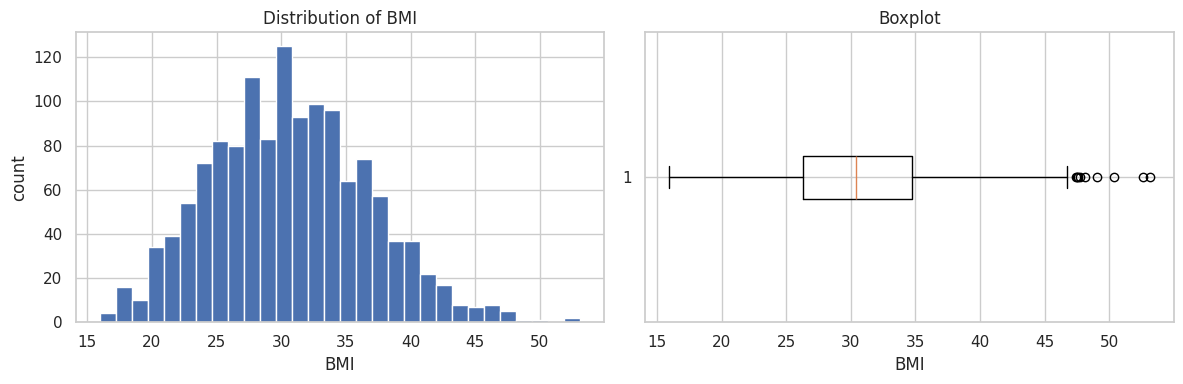

In [12]:
bmi = insurance["bmi"].dropna().values

print(pd.Series(bmi).describe())
print(f"\nskewness: {stats.skew(bmi):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.hist(bmi, bins=30, edgecolor="white")
ax1.set_xlabel("BMI"); ax1.set_ylabel("count"); ax1.set_title("Distribution of BMI")
ax2.boxplot(bmi, vert=False); ax2.set_xlabel("BMI"); ax2.set_title("Boxplot")
plt.tight_layout(); plt.show()

**Discussion (EDA).** BMI is centered near a mean of 30.7 and median of 30.4 (close together), with std ~6.1 and only a mild right skew (~0.28) and a few high-end outliers. It is *close to* normal but not perfectly so — this is a genuine judgment call, unlike the clearly-normal trout and clearly-skewed days.

**Mean model with error bounds.** Because the skew is mild and n is large (1338), the normal-theory interval should be fine, but we verify against a bootstrap.

In [13]:
n = len(bmi)
mean = np.mean(bmi); std = np.std(bmi, ddof=1); sem = std/np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
nt_lo, nt_hi = mean - t_crit*sem, mean + t_crit*sem

boot_means = [np.mean(rng.choice(bmi, n, replace=True)) for _ in range(10000)]
bs_lo, bs_hi = np.percentile(boot_means, [2.5, 97.5])

print(f"Mean BMI: {mean:.2f}")
print(f"Normal-theory 95% CI: [{nt_lo:.2f}, {nt_hi:.2f}]")
print(f"Bootstrap     95% CI: [{bs_lo:.2f}, {bs_hi:.2f}]")

Mean BMI: 30.66
Normal-theory 95% CI: [30.34, 30.99]
Bootstrap     95% CI: [30.33, 31.00]


**Interpretation.** Average BMI is **30.7**, 95% CI ~**[30.3, 31.0]**. The bootstrap and normal-theory intervals are essentially identical, confirming the mild skew doesn't undermine the analytical interval at this sample size.

**Data generating story.** Like trout length, BMI is driven by many additive factors (genetics, diet, activity, age), which by the CLT pushes toward a Normal shape. The mild right skew is expected for a strictly-positive body measurement — there's a hard floor but no hard ceiling, so the upper tail stretches a bit. A Normal model is a reasonable approximation; a slightly skewed alternative (e.g., lognormal) would be the refinement if we needed the tail to be exact.

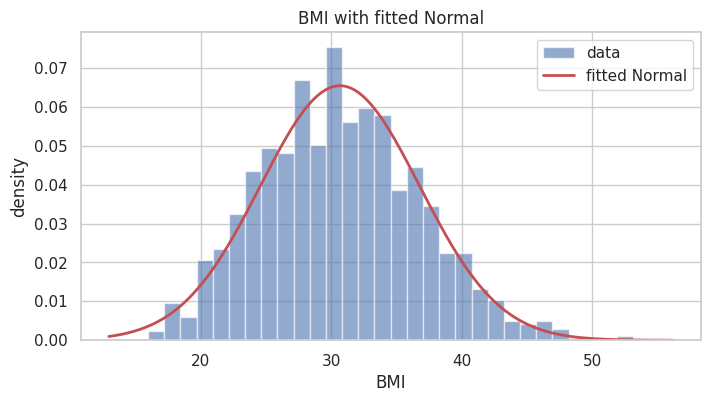

(a) P(BMI > 30, obese) = 0.543
(b) 90th percentile BMI = 38.5
(c) 95% prediction interval for one new person = [18.7, 42.6]


In [14]:
# Fit Normal and overlay
mu, sigma = mean, std
xs = np.linspace(bmi.min()-3, bmi.max()+3, 300)
plt.figure(figsize=(8,4))
plt.hist(bmi, bins=30, density=True, edgecolor="white", alpha=0.6, label="data")
plt.plot(xs, stats.norm.pdf(xs, mu, sigma), "r-", lw=2, label="fitted Normal")
plt.xlabel("BMI"); plt.ylabel("density"); plt.legend()
plt.title("BMI with fitted Normal"); plt.show()

# --- Three predictions ---
p_obese = 1 - stats.norm.cdf(30, mu, sigma)         # BMI >= 30 is the obesity threshold
p90 = stats.norm.ppf(0.90, mu, sigma)
margin = t_crit * sigma * np.sqrt(1 + 1/n)
print(f"(a) P(BMI > 30, obese) = {p_obese:.3f}")
print(f"(b) 90th percentile BMI = {p90:.1f}")
print(f"(c) 95% prediction interval for one new person = [{mu-margin:.1f}, {mu+margin:.1f}]")

**Interpretation of predictions.** (a) About 54% of people in this population have a BMI over 30 (the obesity threshold) — consistent with the mean sitting right at 30.7. (b) 90% of people have BMI below ~38.5. (c) A single new person's BMI falls in roughly **[18.7, 42.6]** with 95% probability. As in Problem 1, note how much wider this prediction interval is than the ±0.3 confidence interval on the mean — same lesson: σ vs. SEM.